# CNN Binary Classification

CNN 이진분류

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

# 데이터 불러오기

In [2]:
!gdown https://drive.google.com/uc?id=1dC-Kso5FonYWtbxtJnJ8_dxO_Jlo8weR

Downloading...
From (original): https://drive.google.com/uc?id=1dC-Kso5FonYWtbxtJnJ8_dxO_Jlo8weR
From (redirected): https://drive.google.com/uc?id=1dC-Kso5FonYWtbxtJnJ8_dxO_Jlo8weR&confirm=t&uuid=812b679c-8ac5-4007-a2b4-37fc437b135b
To: /content/cats_and_dogs.zip
100% 68.6M/68.6M [00:00<00:00, 165MB/s]


In [3]:
!unzip /content/cats_and_dogs.zip

Archive:  /content/cats_and_dogs.zip
   creating: cats_and_dogs/
   creating: cats_and_dogs/test/
   creating: cats_and_dogs/test/cats/
  inflating: cats_and_dogs/test/cats/cat.2300.jpg  
  inflating: cats_and_dogs/test/cats/cat.2301.jpg  
  inflating: cats_and_dogs/test/cats/cat.2302.jpg  
  inflating: cats_and_dogs/test/cats/cat.2303.jpg  
  inflating: cats_and_dogs/test/cats/cat.2304.jpg  
  inflating: cats_and_dogs/test/cats/cat.2305.jpg  
  inflating: cats_and_dogs/test/cats/cat.2306.jpg  
  inflating: cats_and_dogs/test/cats/cat.2307.jpg  
  inflating: cats_and_dogs/test/cats/cat.2308.jpg  
  inflating: cats_and_dogs/test/cats/cat.2309.jpg  
  inflating: cats_and_dogs/test/cats/cat.2310.jpg  
  inflating: cats_and_dogs/test/cats/cat.2311.jpg  
  inflating: cats_and_dogs/test/cats/cat.2312.jpg  
  inflating: cats_and_dogs/test/cats/cat.2313.jpg  
  inflating: cats_and_dogs/test/cats/cat.2314.jpg  
  inflating: cats_and_dogs/test/cats/cat.2315.jpg  
  inflating: cats_and_dogs/test/

# 데이터 분리

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/content/cats_and_dogs'
VAL_SPLIT_RATIO = 0.2

In [5]:
train_dataset = keras.utils.image_dataset_from_directory(
    directory = DATA_DIR + '/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = BATCH_SIZE,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    shuffle = True,
    seed = SEED,
    validation_split = 0.2,
    subset = "training",
)

Found 2600 files belonging to 2 classes.
Using 2080 files for training.


In [6]:
val_dataset = keras.utils.image_dataset_from_directory(
    directory= DATA_DIR + "/train",
    labels="inferred",
    label_mode='int',
    batch_size= BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    subset="validation",
    shuffle=True,
    validation_split=0.2,
    seed=SEED
)

Found 2600 files belonging to 2 classes.
Using 520 files for validation.


In [7]:
test_dataset = keras.utils.image_dataset_from_directory(
    directory = DATA_DIR + '/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = BATCH_SIZE,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    shuffle = False,
    seed = SEED
)

Found 400 files belonging to 2 classes.


# EDA

In [8]:
for images, labels in train_dataset.take(1):
  break

len(images), len(labels)

(32, 32)

### 랜덤 확인

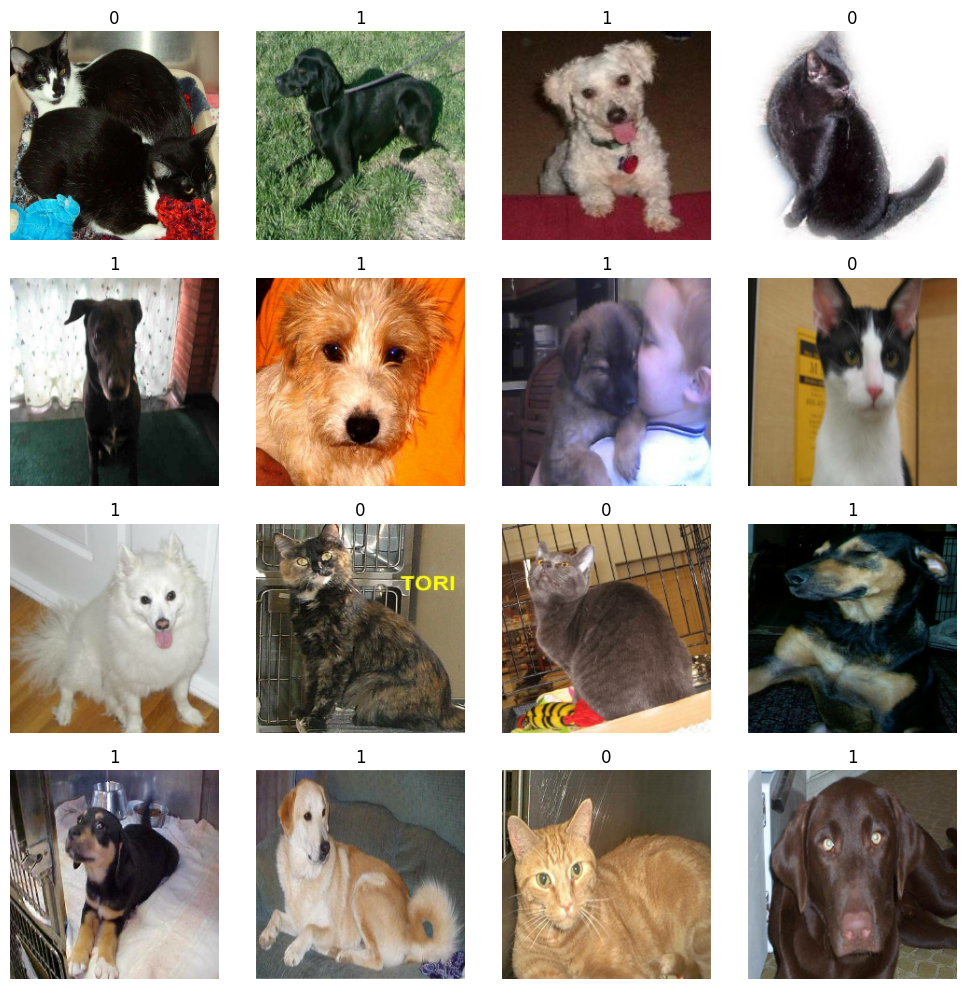

In [9]:
num_to_display = 16
plt.figure(figsize=(10, 10))
for i in range(num_to_display):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype(np.uint8))
    label_index = labels[i].numpy()
    plt.title(label_index)
    plt.axis("off")
plt.tight_layout()
plt.show()

# 전처리

## Scaling

In [10]:
normalization = keras.layers.Rescaling(1./255)

def process_image(x, y):
    x = tf.image.resize(x, [224, 224])
    x = normalization(x)
    return x, y

In [11]:
train_dataset = train_dataset.map(process_image)
val_dataset = val_dataset.map(process_image)

In [12]:
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# 모델 정의

In [13]:
from keras import layers

def build_basic_model():
  model = keras.Sequential([
        keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
        layers.Conv2D(filters=16, kernel_size=(3, 3), activation="relu"),
        layers.MaxPool2D(pool_size=(2, 2)),

        layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPool2D(pool_size=(2, 2)),
        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(2, activation="softmax"),  # 2진분류이지만 다중분류로 출력
    ])
  return model

In [14]:
model = build_basic_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    23,888,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,901,506 (91.18 MB)

 Trainable params: 23,901,506 (91.18 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
def build_batchnorm_model():
    # 2진분류를 2-class softmax(다중분류 형태)로 학습
    model = keras.Sequential([
        keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPool2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPool2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPool2D((2, 2)),

        layers.GlobalAveragePooling2D(),   # Flatten 대신
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(2, activation="softmax"),  # 2진분류이지만 다중분류로 출력
    ])
    return model

In [16]:
model = build_batchnorm_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,530 (400.51 KB)

 Trainable params: 102,082 (398.76 KB)

 Non-trainable params: 448 (1.75 KB)

# 컴파일

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001), # 학습율을 0.001에서 0.0001로 변경
    loss="sparse_categorical_crossentropy",
    metrics=["acc"]
)

# 학습

In [18]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset
)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - acc: 0.5673 - loss: 0.7217 - val_acc: 0.4942 - val_loss: 0.6959
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - acc: 0.5899 - loss: 0.6785 - val_acc: 0.4942 - val_loss: 0.7202
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - acc: 0.6106 - loss: 0.6540 - val_acc: 0.4942 - val_loss: 0.7762
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - acc: 0.6173 - loss: 0.6439 - val_acc: 0.4942 - val_loss: 0.7926
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - acc: 0.6413 - loss: 0.6243 - val_acc: 0.5077 - val_loss: 0.7535
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - acc: 0.6438 - loss: 0.6142 - val_acc: 0.5308 - val_loss: 0.7083
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - acc: 0.6442 - loss: 0.6137 - val_acc: 0.5654 - val_loss: 0.6758
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - acc: 0.6644 - loss: 0.6028 - val_acc: 0.5962 - val_loss: 0.6519
Epoch 9/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - acc: 0.

## 학습 결과 그래프

In [19]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

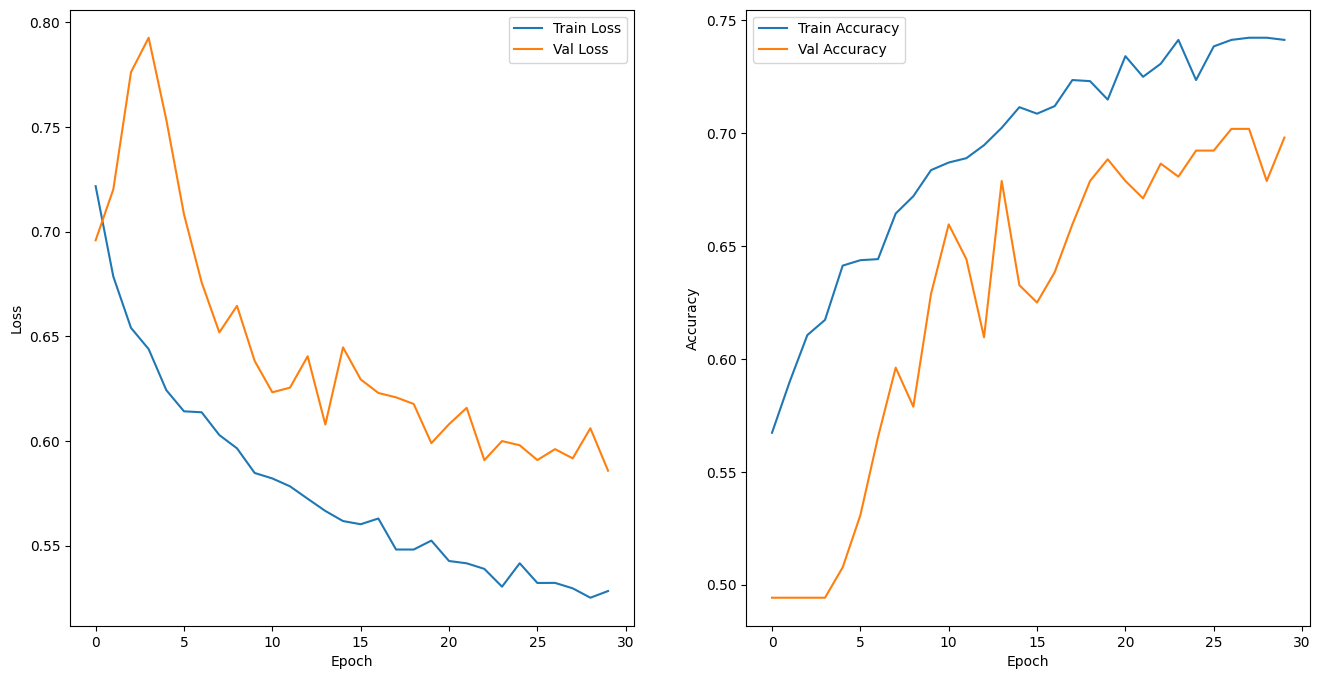

In [20]:
plot_history(history)